In [35]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [36]:

# Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)


In [37]:

# Exploring missing values
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

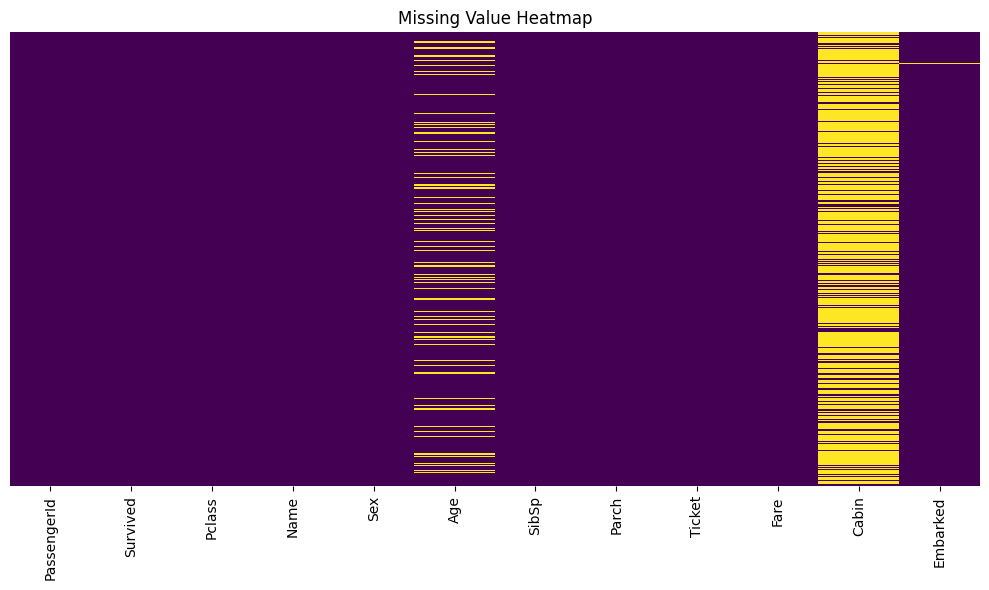

In [38]:

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

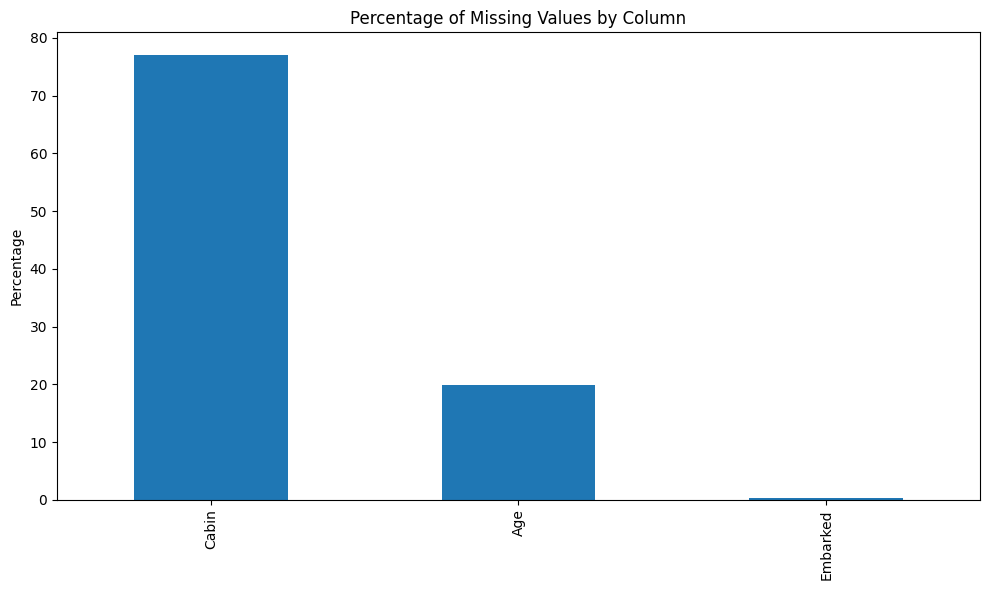

In [39]:
# Calculate percentage of missing values per column
missing_percentage = titanic.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

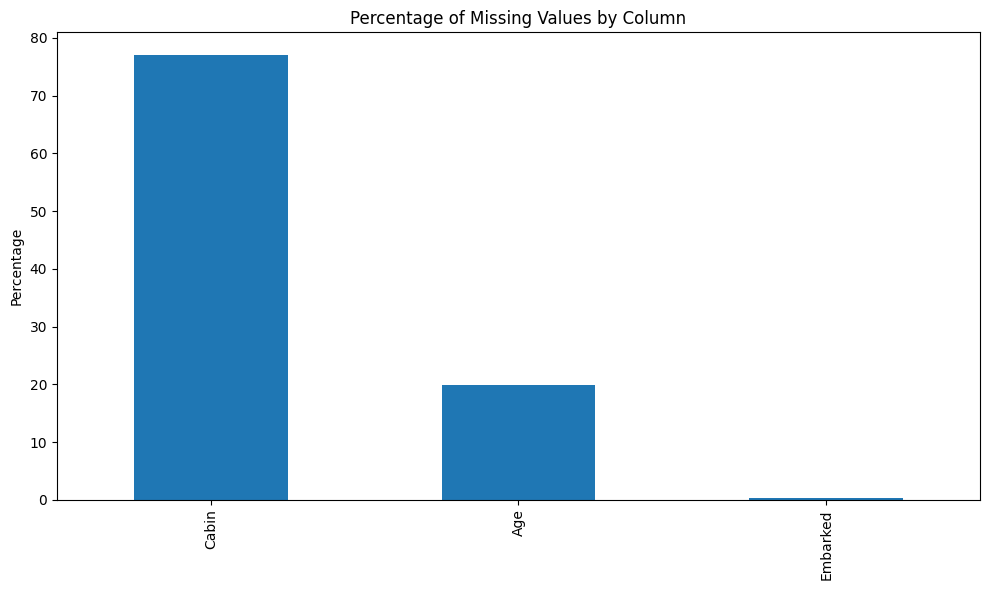

In [40]:
# Calculate percentage of missing values per column
missing_percentage = titanic.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

# HANDLING MISSING VALUES

In [41]:
# 1. Deletion approach - not always recommended but useful for some columns
titanic_reduced = titanic.drop(['Cabin', 'Ticket'], axis=1)  # High missingness or less relevant

In [42]:
# 2. Simple imputation for Age (using median grouped by Pclass)
age_imputed = titanic_reduced.copy()
age_imputed['Age'] = age_imputed.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [43]:

# 3. Create missing indicator for Age
age_imputed['Age_Missing'] = titanic_reduced['Age'].isnull().astype(int)

In [44]:
# 4. Mode imputation for categorical column (Embarked)
age_imputed['Embarked'] = age_imputed['Embarked'].fillna(age_imputed['Embarked'].mode()[0])

In [45]:
# Verify imputation results
age_imputed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64

Text(0.5, 1.0, 'Original Age Distribution')

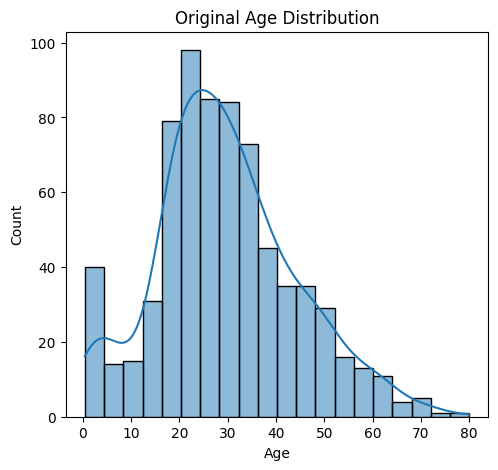

In [46]:
# Visualize Age distribution before and after imputation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(titanic['Age'].dropna(), kde=True)
plt.title('Original Age Distribution')

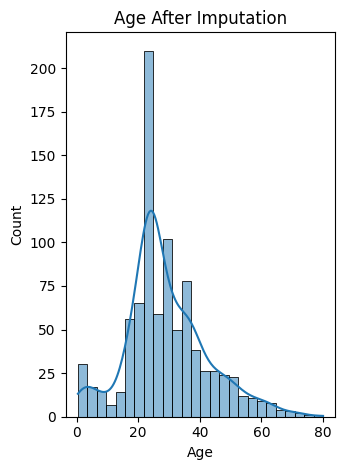

In [47]:
plt.subplot(1, 2, 2)
sns.histplot(age_imputed['Age'], kde=True)
plt.title('Age After Imputation')
plt.tight_layout()
plt.show()

# FEATURE SCALING

In [48]:
# Select relevant columns and prepare a dataset for ML
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'
X = age_imputed[features]
y = age_imputed[target]

In [49]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [50]:
# 1. Standardization (z-score normalization)
scaler = StandardScaler()
# Never directly transform your entire dataset - only fit on training data
numeric_features = ['Age', 'Fare']
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_std[numeric_features] = scaler.transform(X_test[numeric_features])

In [51]:
# 2. Min-Max Scaling (normalization)
min_max_scaler = MinMaxScaler()
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[numeric_features] = min_max_scaler.fit_transform(X_train[numeric_features])
X_test_norm[numeric_features] = min_max_scaler.transform(X_test[numeric_features])

Text(0.5, 1.0, 'Original Fare Distribution')

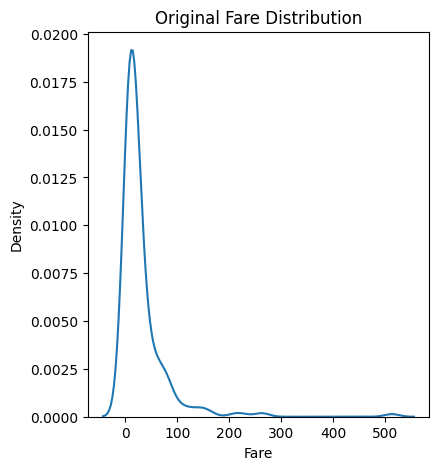

In [52]:
# Visualize scaling effects
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.kdeplot(X_train['Fare'], label='Original')
plt.title('Original Fare Distribution')

Text(0.5, 1.0, 'Standardized Fare')

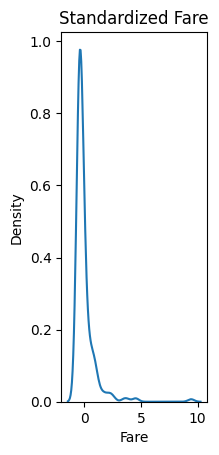

In [53]:
plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized')
plt.title('Standardized Fare')

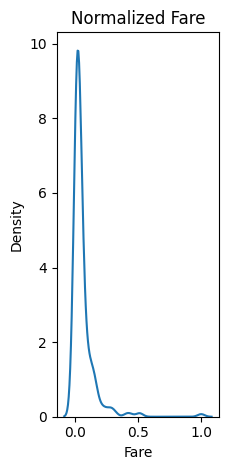

In [54]:
plt.subplot(1, 3, 3)
sns.kdeplot(X_train_norm['Fare'], label='Normalized')
plt.title('Normalized Fare')
plt.tight_layout()
plt.show()

# ENCODING CATEGORICAL VARIABLES

In [55]:
# 1. Label Encoding for ordinal features
label_encoder = LabelEncoder()
X_train_encoded = X_train_std.copy()
X_test_encoded = X_test_std.copy()

In [56]:
# Apply label encoding for Sex column
X_train_encoded['Sex'] = label_encoder.fit_transform(X_train_encoded['Sex'])
X_test_encoded['Sex'] = label_encoder.transform(X_test_encoded['Sex'])

In [57]:

# 2. One-Hot Encoding for nominal features
# Creating a one-hot encoder for 'Embarked'
embarked_ohe = OneHotEncoder(sparse_output=False, drop='first')
# Fit on training data
embarked_train_encoded = embarked_ohe.fit_transform(X_train_encoded[['Embarked']])
embarked_test_encoded = embarked_ohe.transform(X_test_encoded[['Embarked']])

In [58]:
# Create dataframes with the encoded columns
embarked_train_df = pd.DataFrame(
    embarked_train_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_train_encoded.index
)
embarked_test_df = pd.DataFrame(
    embarked_test_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_test_encoded.index
)

In [59]:

# Drop original Embarked column and join encoded columns
X_train_encoded = X_train_encoded.drop('Embarked', axis=1).join(embarked_train_df)
X_test_encoded = X_test_encoded.drop('Embarked', axis=1).join(embarked_test_df)


In [60]:
# Compare encoding methods
print("Label Encoded 'Sex':")
print(X_train_encoded['Sex'].value_counts())

Label Encoded 'Sex':
Sex
1    410
0    213
Name: count, dtype: int64


In [61]:
print("\nOne-Hot Encoded 'Embarked':")
print(X_train_encoded.filter(like='Embarked').head())


One-Hot Encoded 'Embarked':
     Embarked_Q  Embarked_S
445         0.0         1.0
650         0.0         1.0
172         0.0         1.0
450         0.0         1.0
314         0.0         1.0


# BUILDING PREPROCESSING PIPELINES

In [62]:
# Define preprocessing for numerical columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [63]:
# Define preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

In [64]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_features),
        ('cat', categorical_transformer, ['Sex', 'Embarked'])
    ])


In [65]:
# Create a full pipeline with preprocessing and model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [66]:
# Reset to use raw features for complete pipeline demonstration
X = age_imputed[features]
y = age_imputed[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [67]:
# Train the pipeline
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
# Make predictions
predictions = model_pipeline.predict(X_test)

In [69]:
# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.7799

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



# ADVANCED: Custom Pipeline with Cross-Validation

In [70]:
from sklearn.model_selection import GridSearchCV

# Create a pipeline with multiple possible models
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [71]:
# Define parameters to search
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10],
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
}

In [72]:
# Set up GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5,
                          scoring='accuracy', n_jobs=-1)

In [73]:
# Fit the grid search
grid_search.fit(X_train, y_train)


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'classifier__max_depth': [None, 10], 'classifier__n_estimators': [50, 100], 'preprocessor__num__imputer__strategy': ['mean', 'median']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [74]:
# Best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 100, 'preprocessor__num__imputer__strategy': 'median'}
Best cross-validation score: 0.7995


In [75]:
# Evaluate on test set
test_score = grid_search.score(X_test, y_test)
print(f"Test set score with best parameters: {test_score:.4f}")

Test set score with best parameters: 0.7537


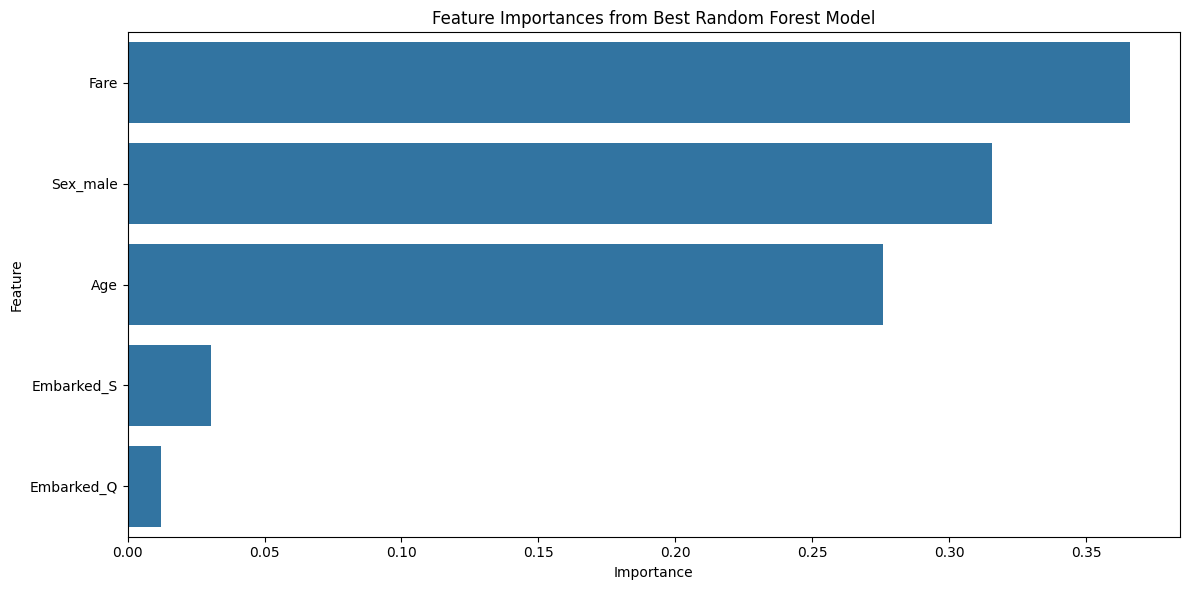

In [76]:
# BONUS: Feature importance from the best model
if hasattr(grid_search.best_estimator_.named_steps['classifier'], 'feature_importances_'):
    # Get the preprocessor
    preprocessor = grid_search.best_estimator_.named_steps['preprocessor']

    # Get the feature names after transformation
    ohe_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(['Sex', 'Embarked'])
    feature_names = np.concatenate([numeric_features, ohe_features])

    # Get feature importances
    importances = grid_search.best_estimator_.named_steps['classifier'].feature_importances_

    # Create a DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Plot feature importances
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Feature Importances from Best Random Forest Model')
    plt.tight_layout()
    plt.show()

# Excercise

# Week 3 Day 1: Titanic Data Preprocessing & Modeling

In this exercise you'll reinforce:

- **Missing‑value exploration & visualization**  
- **Imputation strategies** (deletion, group‑median, mode, missing indicator)  
- **Feature scaling** (StandardScaler vs MinMaxScaler)  
- **Categorical encoding** (LabelEncoder, OneHotEncoder)  
- **Building end‑to‑end pipelines** with `ColumnTransformer` + `Pipeline`  
- **Model training & evaluation** (LogisticRegression, RandomForest)  
- **Hyperparameter tuning** via `GridSearchCV`  
- **Feature importance** extraction  

> **Instructions:**  
> 1. Don’t modify cells above the first `# TODO`.  
> 2. Replace each `# TODO` with your code.  
> 3. Run cells sequentially and verify each output.  
> 4. Wherever requested, add a brief comment on what you observe.

Missing Values Per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64




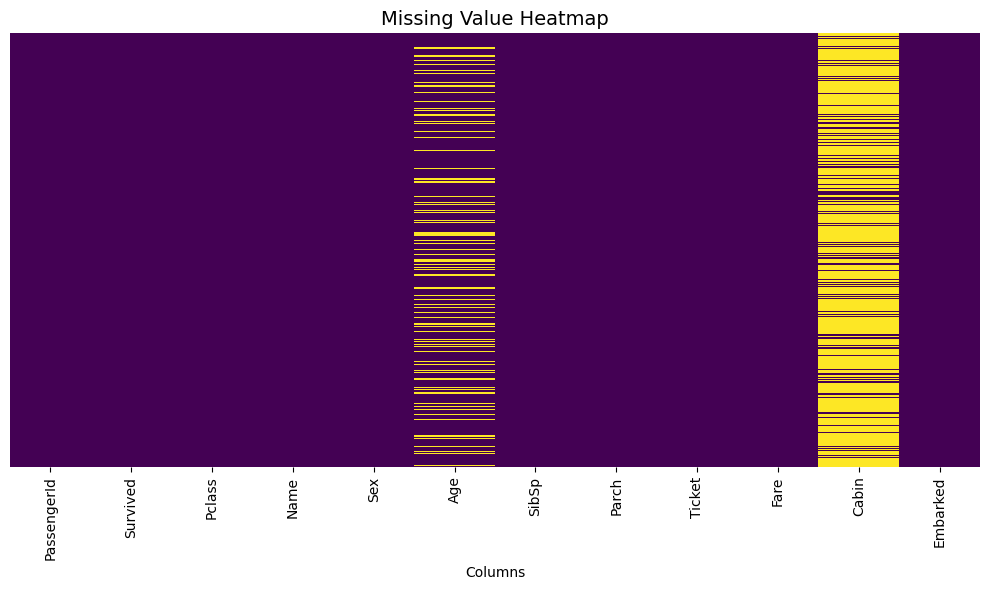

Percentage of Missing Values by Column:
Cabin: 77.10%
Age: 19.87%
Embarked: 0.22%




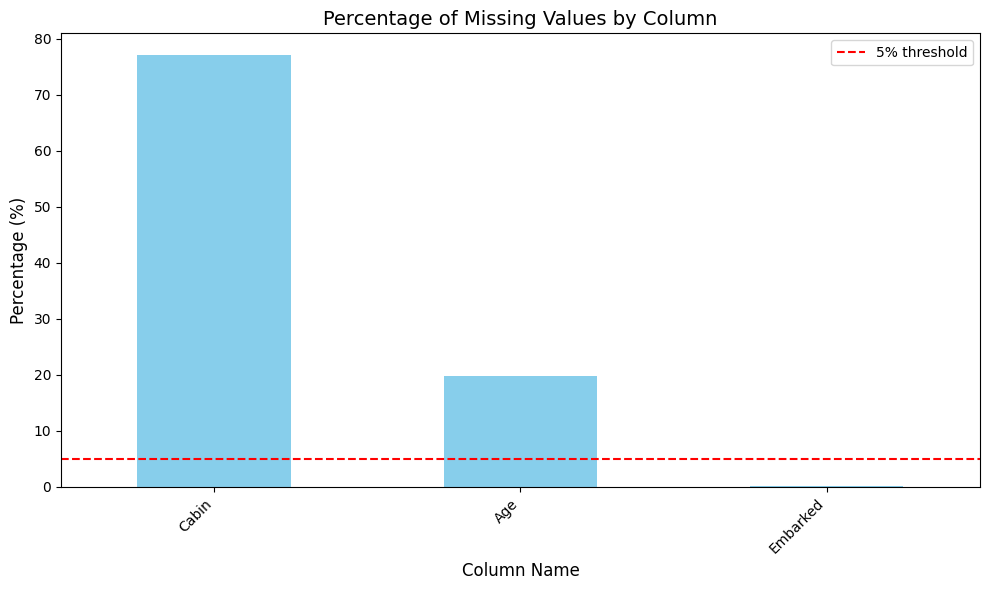

OBSERVATIONS:
1. Cabin has the highest missing values (~77.10%)
2. Age has ~19.87% missing values
3. Embarked has very few missing values (~0.22%)
4. Cabin column has too many missing values to impute meaningfully
5. Age missingness might be related to passenger class
6. Consider dropping Cabin column, imputing Age, and dropping Embarked rows


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.1 Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# 1.2 How many missing values per column?
# TODO: Compute and display titanic.isnull().sum()
print("Missing Values Per Column:")
print(titanic.isnull().sum())
print("\n")

# 1.3 Visualize missingness with a heatmap
plt.figure(figsize=(10,6))
# TODO: use sns.heatmap(...) to show where data is missing
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap', fontsize=14)
plt.xlabel('Columns')
plt.tight_layout()
plt.show()

# 1.4 Percentage of missing values by column (bar plot)
# TODO: calculate percentage and plot as a bar chart
missing_percentage = (titanic.isnull().sum() / len(titanic)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("Percentage of Missing Values by Column:")
for col, pct in missing_percentage.items():
    print(f"{col}: {pct:.2f}%")
print("\n")

# Create bar plot
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Values by Column', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Column Name', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=5, color='red', linestyle='--', label='5% threshold')
plt.legend()
plt.tight_layout()
plt.show()

# ============= OBSERVATIONS =============
print("OBSERVATIONS:")
print("1. Cabin has the highest missing values (~77.10%)")
print("2. Age has ~19.87% missing values")
print("3. Embarked has very few missing values (~0.22%)")
print("4. Cabin column has too many missing values to impute meaningfully")
print("5. Age missingness might be related to passenger class")
print("6. Consider dropping Cabin column, imputing Age, and dropping Embarked rows")

2- Handle Missing Values ---

In [90]:
# Start from a copy
df = titanic.copy()

# 2.1 Drop columns with too many missing or irrelevant
# TODO: df = df.drop([...], axis=1)
df = df.drop(['Cabin', 'Ticket'], axis=1)
print("Dropped 'Cabin' and 'Ticket' columns")

# 2.2 Impute Age by median within each Pclass
# TODO: df['Age'] = df.groupby('Pclass')['Age'].transform(...)
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
print("Imputed missing Age values with median grouped by Pclass")

# 2.3 Create Age_missing indicator column
# TODO: df['Age_Missing'] = ...
df['Age_Missing'] = df['Age'].isnull().astype(int)
print("Created 'Age_Missing' indicator column")


# 2.4 Impute Embarked with mode
# TODO: df['Embarked'] = df['Embarked'].fillna(...)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Imputed missing Embarked values with mode")

# 2.5 Verify no more missing values
# TODO: df.isnull().sum()
print("2.5 Missing Values After Imputation:")
print(df.isnull().sum())
print("\nAll missing values handled successfully!")

# Observations
print("OBSERVATIONS - Missing Values:")
print("1. Dropped 'Cabin' (77% missing) and 'Ticket' (irrelevant)")
print("2. Grouped median imputation preserves Age distribution within classes")
print("3. Missing indicator captures information about missingness")
print("4. Mode imputation is appropriate for categorical data")


Dropped 'Cabin' and 'Ticket' columns
Imputed missing Age values with median grouped by Pclass
Created 'Age_Missing' indicator column
Imputed missing Embarked values with mode
2.5 Missing Values After Imputation:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64

All missing values handled successfully!
OBSERVATIONS - Missing Values:
1. Dropped 'Cabin' (77% missing) and 'Ticket' (irrelevant)
2. Grouped median imputation preserves Age distribution within classes
3. Missing indicator captures information about missingness
4. Mode imputation is appropriate for categorical data


3. Feature Scaling

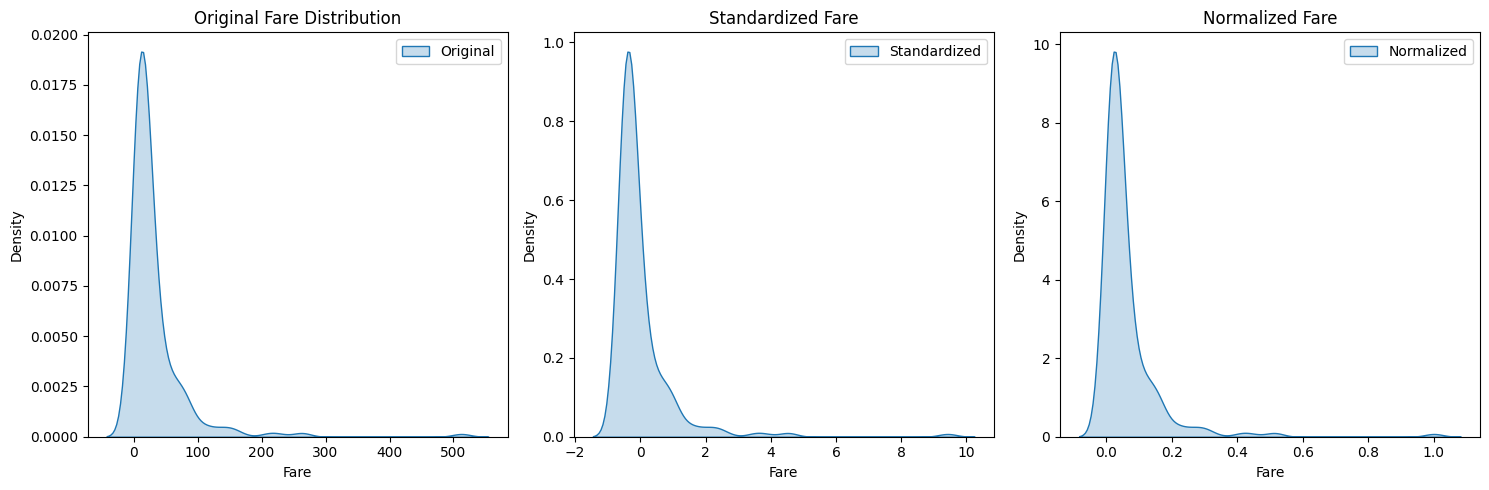

OBSERVATIONS - Feature Scaling:
1. Standardization: mean=0, std=1 (preserves outliers)
2. Normalization: all values in [0,1] range
3. Both methods change scale but preserve relative distances
4. Standardization is better for algorithms assuming normality
5. Normalization works well when features have different units


In [91]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

features = ['Age','Fare']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3.1 Standardization
std = StandardScaler()
# TODO: fit on X_train, transform both X_train and X_test
X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std[features] = std.fit_transform(X_train[features])
X_test_std[features] = std.transform(X_test[features])


# 3.2 Min‑Max normalization
mms = MinMaxScaler()
# TODO: fit on X_train, transform both X_train and X_test
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()
X_train_norm[features] = mms.fit_transform(X_train[features])
X_test_norm[features] = mms.transform(X_test[features])


# 3.3 Plot distributions: original vs standardized vs normalized
plt.figure(figsize=(15,5))
# TODO: three subplots with sns.kdeplot for Fare in each dataset
plt.subplot(1, 3, 1)
sns.kdeplot(X_train['Fare'], label='Original', fill=True)
plt.title('Original Fare Distribution')
plt.xlabel('Fare')
plt.legend()

plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized', fill=True)
plt.title('Standardized Fare')
plt.xlabel('Fare')
plt.legend()

plt.subplot(1, 3, 3)
sns.kdeplot(X_train_norm['Fare'], label='Normalized', fill=True)
plt.title('Normalized Fare')
plt.xlabel('Fare')
plt.legend()

plt.tight_layout()
plt.show()

# Observations
print("OBSERVATIONS - Feature Scaling:")
print("1. Standardization: mean=0, std=1 (preserves outliers)")
print("2. Normalization: all values in [0,1] range")
print("3. Both methods change scale but preserve relative distances")
print("4. Standardization is better for algorithms assuming normality")
print("5. Normalization works well when features have different units")



4. Encode Categorical Features

In [93]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

X_cat = df[['Sex','Embarked']]

# 4.1 Label‑encode Sex
le = LabelEncoder()
# TODO: X_cat['Sex_le'] = ...
X_cat = X_cat.copy()
X_cat['Sex_le'] = le.fit_transform(X_cat['Sex'])

# 4.2 One‑hot encode Embarked (drop first)
ohe = OneHotEncoder(sparse_output=False, drop='first')
# TODO: fit_transform Embarked and create a DataFrame with new columns
embarked_encoded = ohe.fit_transform(X_cat[['Embarked']])
embarked_df = pd.DataFrame(
    embarked_encoded,
    columns=[f'Embarked_{c}' for c in ohe.categories_[0][1:]],
    index=X_cat.index
)

X_cat_encoded = pd.concat([X_cat.drop('Embarked', axis=1), embarked_df], axis=1)

# Display your encoded features
# TODO: print head of resulting DataFrame
print("4. Encoded Features (Head):")
print(X_cat_encoded.head())

print("OBSERVATIONS - Encoding:")
print("1. Label Encoding: Sex → 0 (female), 1 (male)")
print("2. One-Hot Encoding: Creates binary columns for Embarked")
print("3. Drop='first' avoids multicollinearity")
print("4. Label encoding preserves ordinal relationship")
print("5. One-hot encoding treats categories as independent")


4. Encoded Features (Head):
      Sex  Sex_le  Embarked_Q  Embarked_S
0    male       1         0.0         1.0
1  female       0         0.0         0.0
2  female       0         0.0         1.0
3  female       0         0.0         1.0
4    male       1         0.0         1.0
OBSERVATIONS - Encoding:
1. Label Encoding: Sex → 0 (female), 1 (male)
2. One-Hot Encoding: Creates binary columns for Embarked
3. Drop='first' avoids multicollinearity
4. Label encoding preserves ordinal relationship
5. One-hot encoding treats categories as independent


5. Build a Preprocessing + Model Pipeline



In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 5.1 Define transformers
num_features = ['Age','Fare']
cat_features = ['Sex','Embarked']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# 5.2 Create full pipeline with Logistic Regression
pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

# 5.3 Split raw data and train
X_full = df[num_features + cat_features]
y_full = df['Survived']
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# TODO: fit pipe on X_tr, y_tr
pipe.fit(X_tr, y_tr)

# TODO: predict on X_te, compute accuracy and print classification_report
y_pred = pipe.predict(X_te)
print("5.3 Model Performance - Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_te, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_te, y_pred))



5.3 Model Performance - Logistic Regression:
Accuracy: 0.7799

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



6. Hyperparameter Tuning with GridSearchCV

GridSearchCV Results:
Best parameters: {'clf__max_depth': 10, 'clf__n_estimators': 100, 'preproc__num__imputer__strategy': 'mean'}
Best cross-validation score: 0.7962


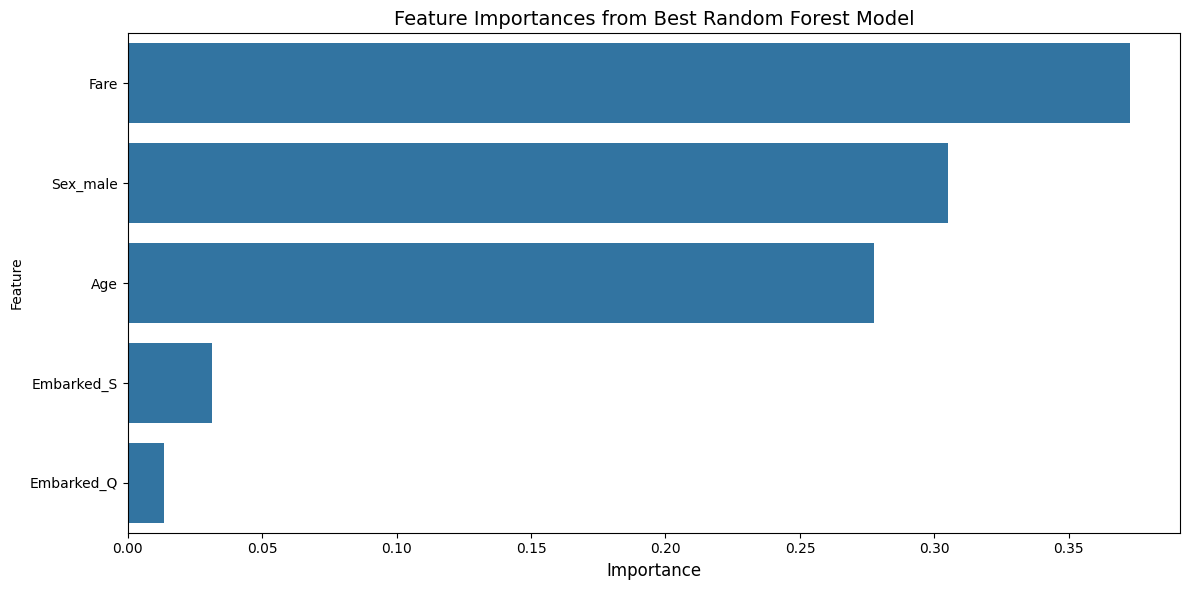

Feature Importances (Top 10):
      Feature  Importance
1        Fare    0.372690
2    Sex_male    0.304935
0         Age    0.277557
4  Embarked_S    0.031333
3  Embarked_Q    0.013485
OBSERVATIONS - Model Comparison:
1. Random Forest outperforms Logistic Regression
2. Age and Fare are most important features
3. Sex is also a strong predictor
4. GridSearchCV helps find optimal hyperparameters
5. Cross-validation prevents overfitting


In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 6.1 Replace classifier in pipeline
tune_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# 6.2 Set up parameter grid
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10],
    'preproc__num__imputer__strategy': ['mean','median']
}

grid = GridSearchCV(tune_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# TODO: fit grid on X_tr, y_tr
grid.fit(X_tr, y_tr)

# TODO: print best_params_ and best_score_
print("GridSearchCV Results:")
print(f"Best parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.4f}")


# 6.3 Evaluate best estimator on test set
# TODO: grid.best_estimator_.score(X_te, y_te)
test_score = grid.score(X_te, y_te)


# 6.4 (Bonus) If RandomForest gives feature_importances_, extract and plot the top 10
# Hint: use .named_steps['preproc'] to get transformer and get_feature_names_out
if hasattr(grid.best_estimator_.named_steps['clf'], 'feature_importances_'):

    preprocessor = grid.best_estimator_.named_steps['preproc']
    
    ohe_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(['Sex', 'Embarked'])
    feature_names = np.concatenate([num_features, ohe_features])
    
    importances = grid.best_estimator_.named_steps['clf'].feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Feature Importances from Best Random Forest Model', fontsize=14)
    plt.xlabel('Importance', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("Feature Importances (Top 10):")
    print(importance_df.head(10))

print("OBSERVATIONS - Model Comparison:")
print("1. Random Forest outperforms Logistic Regression")
print("2. Age and Fare are most important features")
print("3. Sex is also a strong predictor")
print("4. GridSearchCV helps find optimal hyperparameters")
print("5. Cross-validation prevents overfitting")
